In [1]:
# !pip install -e .[cplex]

In [ ]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    RXXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange

from gulps import GulpsDecomposer, logger
from gulps.core.coverage import compute_coverage_statistics
from gulps.core.invariants import GateInvariants
from gulps.core.isa import ContinuousISA, DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.linear_program.cplex_lp import ContinuousISAConstraints
from gulps.viz.invariant_viz import plot_decomposition
from gulps.viz.report_viz import compare_continuous_discrete, report_benchmark_results
from gulps.isa_library.fsim import fsim


Compare continuous ISA (arbitrary gate powers) vs discrete ISA (fixed fractional powers 1/2 through 1/6). The `single_qubit_cost` parameter models overhead from local unitary layers. Try different base gates (RXXGate, iSwap, SWAP, fSim) to see how choice affects costs.

In [ ]:
single_qubit_cost = 0.1
# base_gate = RXXGate(theta=np.pi / 2)
base_gate = iSwapGate()
# base_gate = SwapGate()
# base_gate = fsim(np.pi / 2, np.pi / 6)

continuous_isa = ContinuousISA.from_base_gate(
    base_gate, single_qubit_cost=single_qubit_cost
)
continuous_decomposer = GulpsDecomposer(isa=continuous_isa)
# Warm-start to trigger JIT compilation (optional)
_ = continuous_decomposer(random_unitary(4, seed=0))

In [ ]:
_discrete_isa = [
    (base_gate, 1.0, "2Q"),
    (base_gate.power(1 / 2), 1 / 2, "sqrt2"),
    (base_gate.power(1 / 3), 1 / 3, "sqrt3"),
    # (base_gate.power(1 / 4), 1 / 4, "sqrt4"),
    # (base_gate.power(1 / 5), 1 / 5, "sqrt5"),
    # (base_gate.power(1 / 6), 1 / 6, "sqrt6"),
]
gate_set, costs, names = zip(*_discrete_isa)
discrete_isa = DiscreteISA(gate_set, costs, names, single_qubit_cost=single_qubit_cost)
discrete_decomposer = GulpsDecomposer(isa=discrete_isa)
# Warm-start to trigger JIT compilation (optional)
_ = discrete_decomposer(random_unitary(4, seed=0))

Build discrete ISA with the same base gate for comparison.

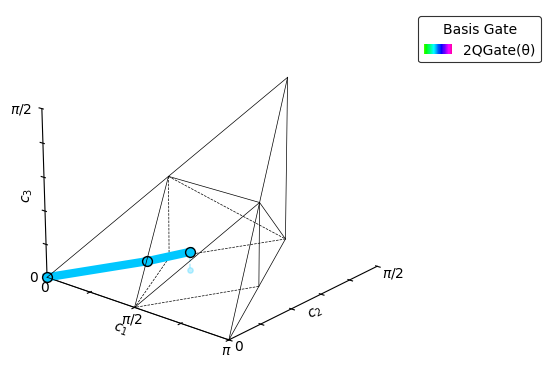

In [5]:
# make animated sequence of cartan trajectory plots, just for fun
from IPython.display import display, clear_output
import time

fig_display = display(display_id=True)

for _i in range(20):
    clear_output(wait=True)
    r = continuous_decomposer._best_decomposition(
        GateInvariants.from_unitary(random_unitary(4))
    )
    fig = plot_decomposition(r.intermediates, r.sentence, continuous_isa, r.parameters)

    display(fig)
    plt.close(fig)
    time.sleep(0.15)  # 150ms delay

In [6]:
logger.setLevel("INFO")
N = 1_000

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        fid = average_gate_fidelity(u, Operator(continuous_decomposer(u)))
        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(continuous_decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

Decomposing random unitaries:   0%|          | 0/1000 [00:00<?, ?it/s]

Decomposing random unitaries: 100%|██████████| 1000/1000 [00:40<00:00, 24.98it/s]


Benchmark: 1000/1000 successful (0 failures)
Fidelity: median=1.0000000000, min=1.0000000000
Avg time: 37.4 ms/decomposition
Cache: 0.2% hit rate (2/1204)


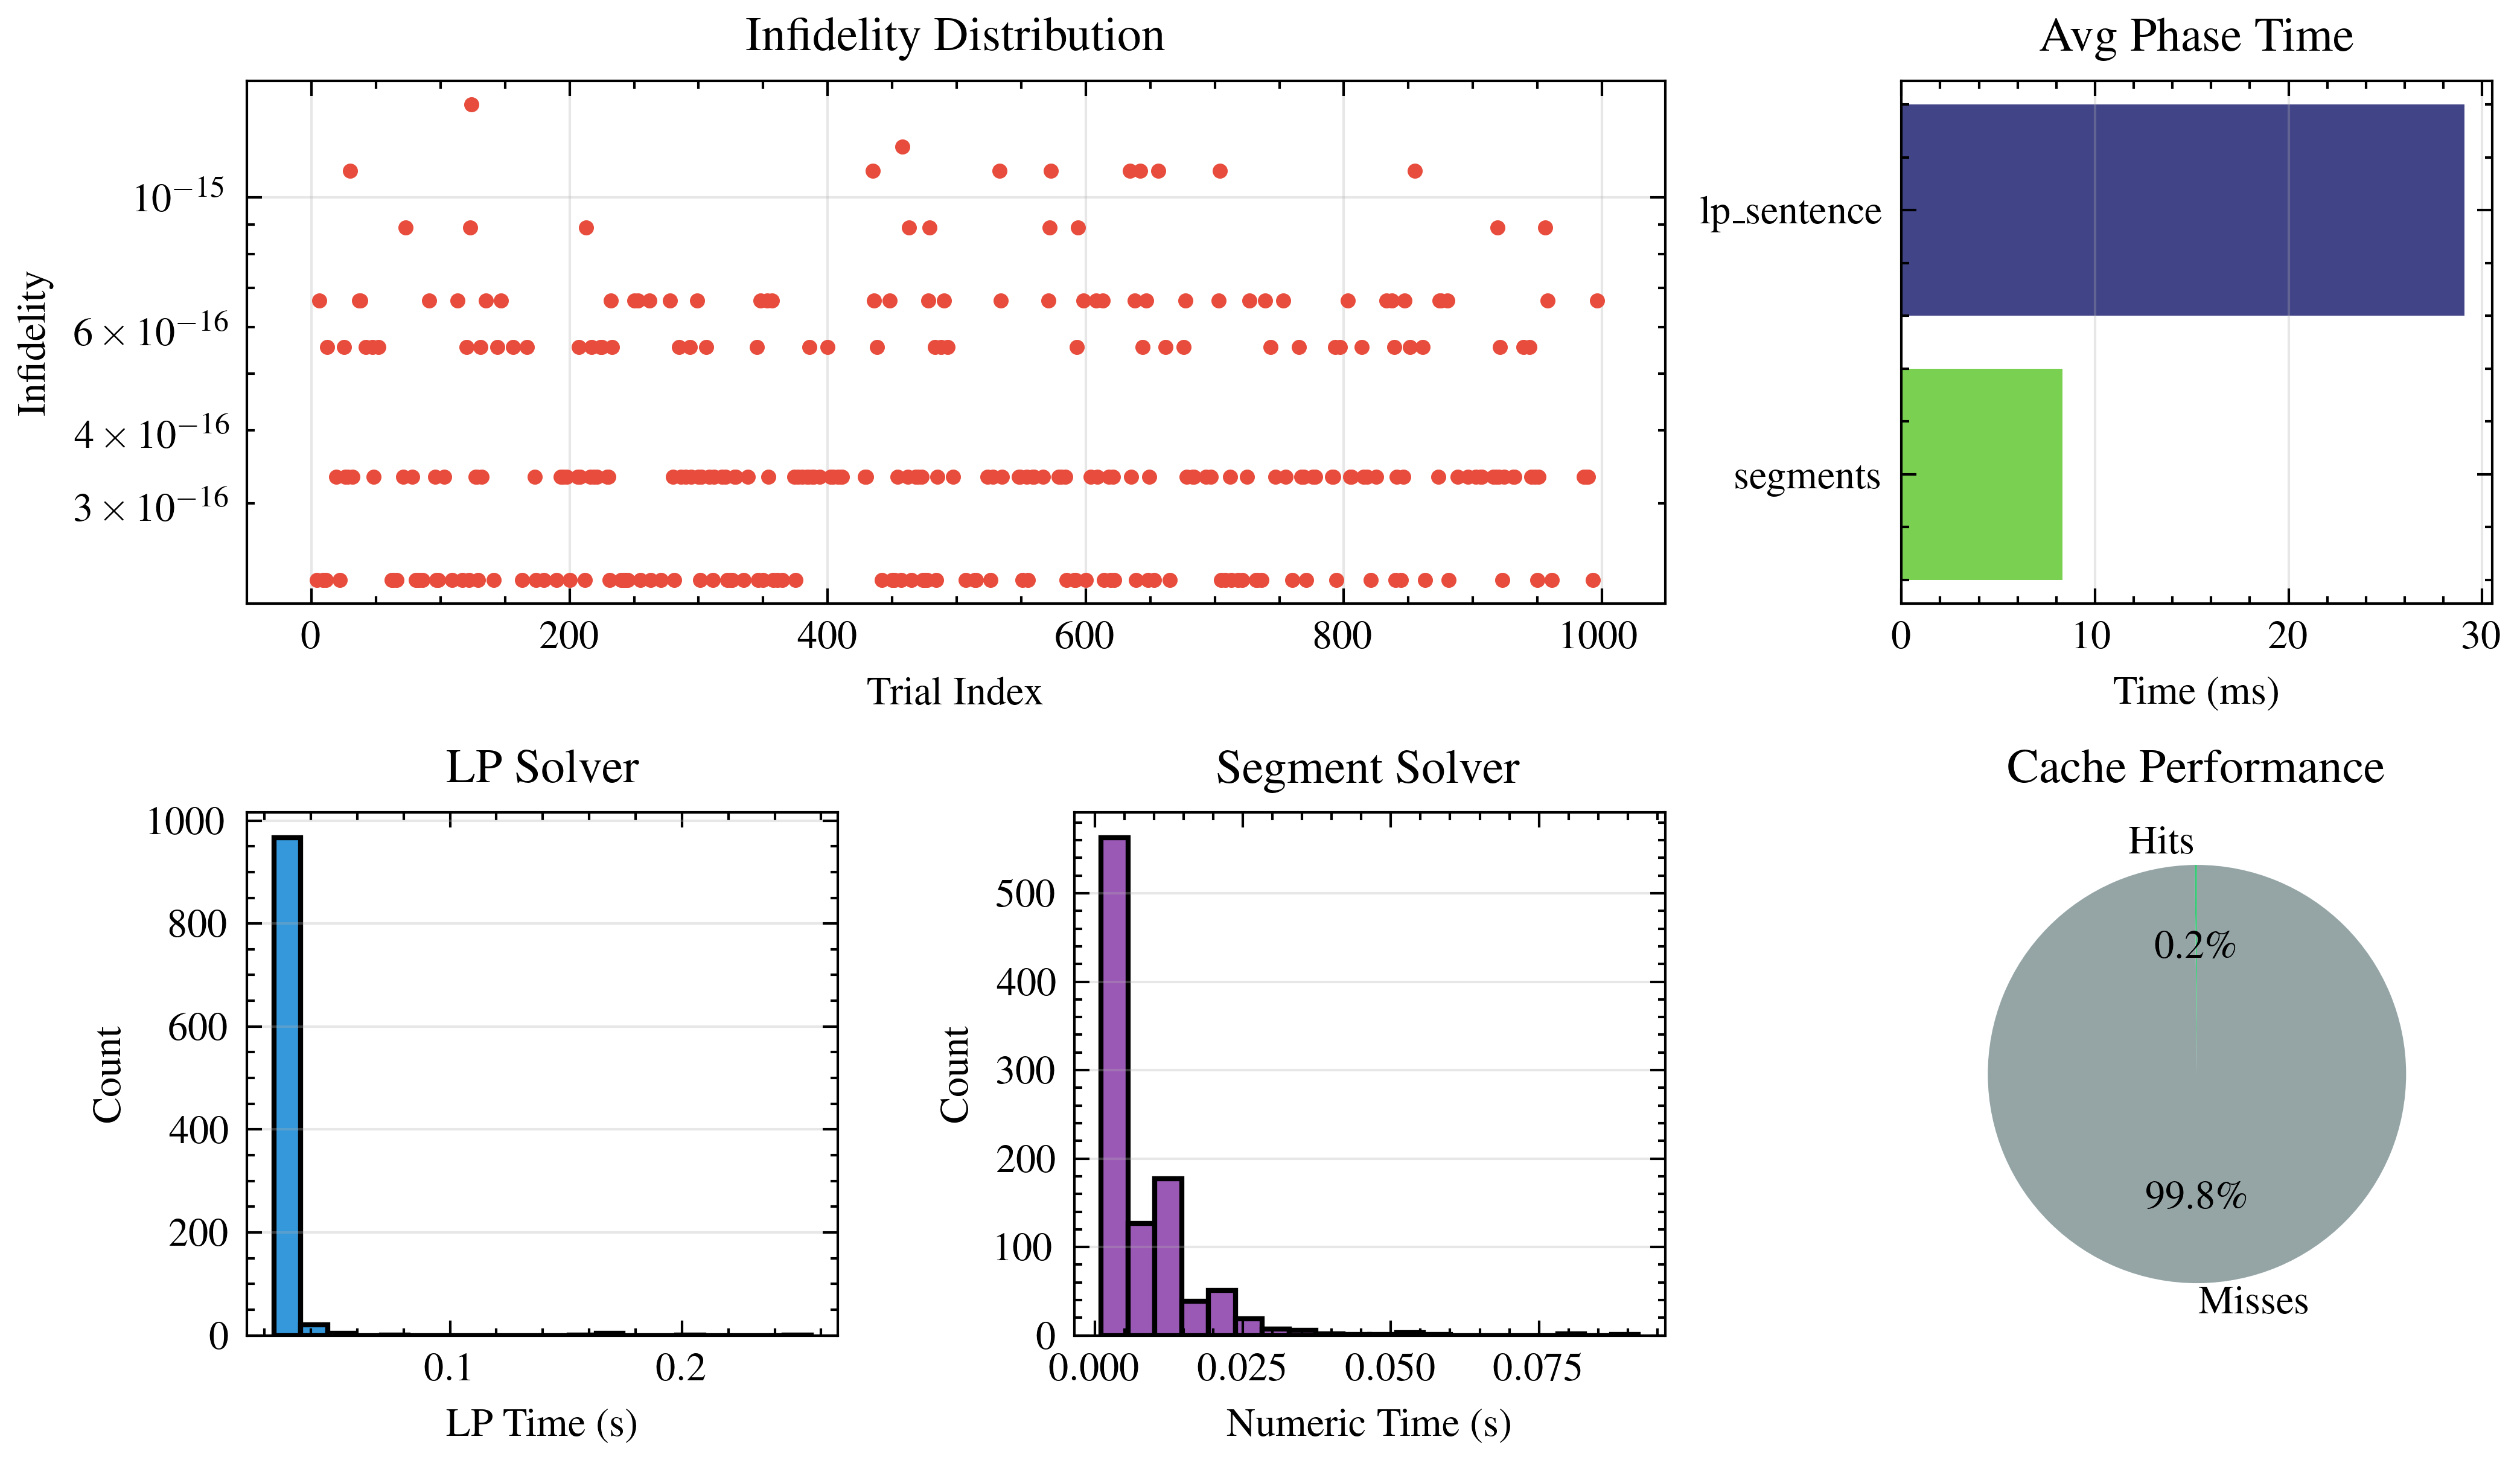

In [7]:
report_benchmark_results(fidelities, all_timings, continuous_decomposer, N, failures)

___

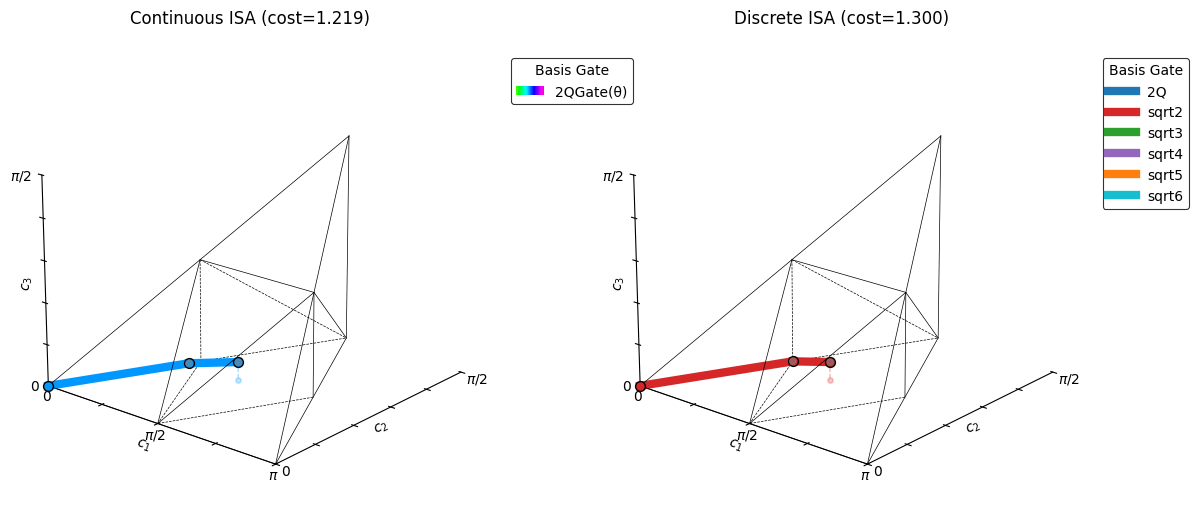

In [8]:
# make animated sequence of cartan trajectory plots, comparing continuous vs discrete
from IPython.display import display, clear_output
import time

for _i in range(20):
    clear_output(wait=True)

    # Use same target for both decomposers
    target = GateInvariants.from_unitary(random_unitary(4, seed=_i + 200))

    # Get decompositions
    r_cts = continuous_decomposer._best_decomposition(target)
    r_disc = discrete_decomposer._best_decomposition(target)

    # Create side-by-side figure
    fig = plt.figure(figsize=(14, 6))

    # Left: Continuous
    ax1 = fig.add_subplot(121, projection="3d")
    plot_decomposition(
        r_cts.intermediates, r_cts.sentence, continuous_isa, r_cts.parameters, ax=ax1
    )
    ax1.set_title(f"Continuous ISA (cost={r_cts.cost:.3f})", pad=20)

    # Right: Discrete
    ax2 = fig.add_subplot(122, projection="3d")
    plot_decomposition(
        r_disc.intermediates, r_disc.sentence, discrete_isa, r_disc.parameters, ax=ax2
    )
    ax2.set_title(f"Discrete ISA (cost={r_disc.cost:.3f})", pad=20)

    display(fig)
    plt.close(fig)
    time.sleep(0.25)  # 150ms delay

Comparing decomposers:   0%|          | 0/1000 [00:00<?, ?it/s]

Comparing decomposers: 100%|██████████| 1000/1000 [00:55<00:00, 17.87it/s]


Collected 1000 decompositions for each ISA


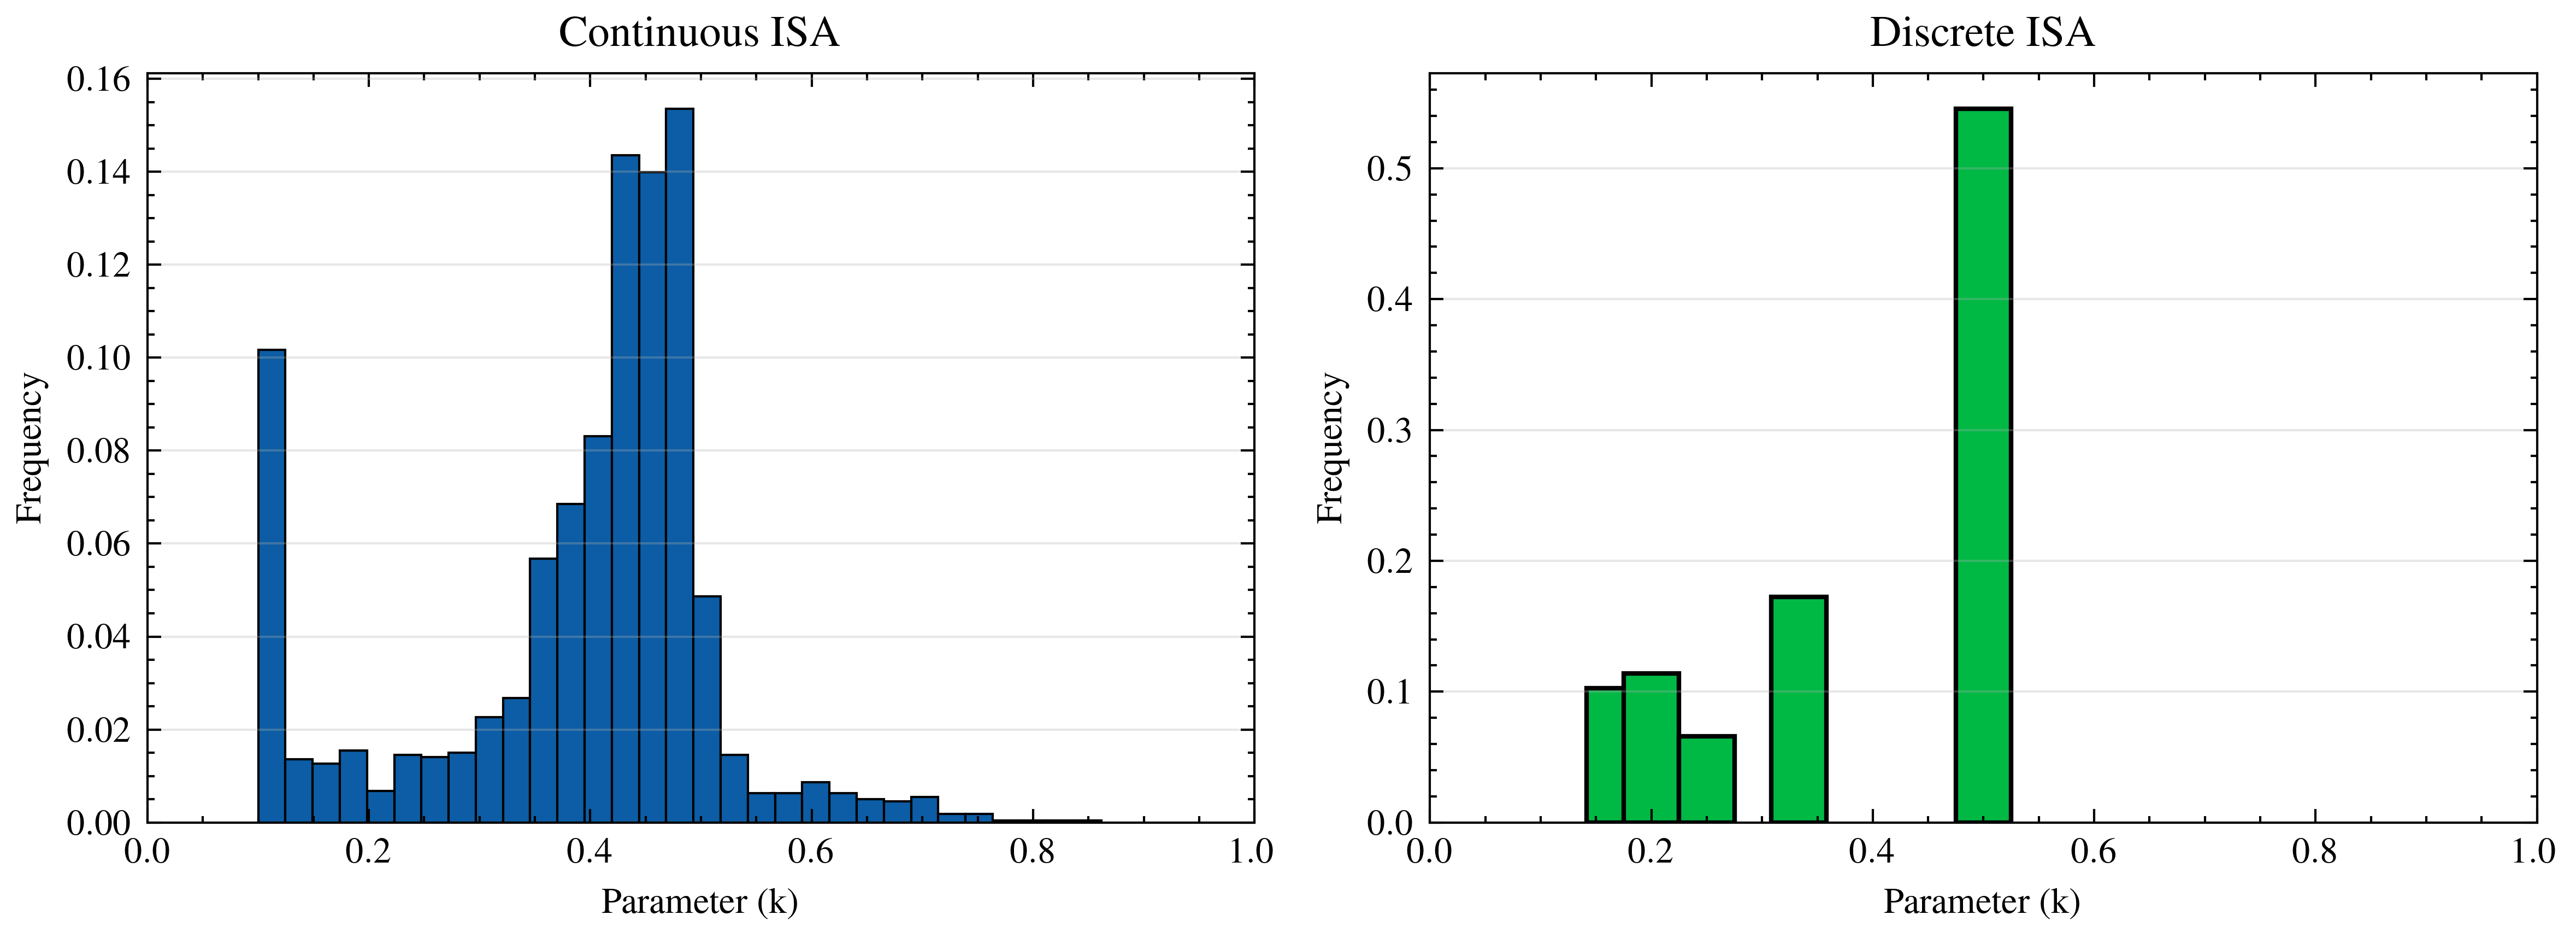

=== Cost Statistics ===
Continuous: mean=1.1766, std=0.1286
Discrete:   mean=1.2320, std=0.1310
Cost improvement: 4.49%


In [ ]:
continuous_params = []
continuous_depth = []
continuous_costs = []
discrete_params = []
discrete_costs = []

for idx in tqdm(range(N), desc="Comparing ISAs"):
    target = GateInvariants.from_unitary(random_unitary(dims=4, seed=idx))

    # Continuous decomposer
    sol_cts = continuous_decomposer._best_decomposition(target)
    continuous_params.extend(sol_cts.parameters)
    continuous_costs.append(sol_cts.cost)
    continuous_depth.append(len(sol_cts.sentence))

    # Discrete decomposer
    sol_disc = discrete_decomposer._best_decomposition(target)
    discrete_params.extend(sol_disc.parameters)
    discrete_costs.append(sol_disc.cost)

print(f"Collected {N} decompositions for each ISA")
compare_continuous_discrete(
    continuous_params,
    continuous_costs,
    discrete_params,
    discrete_costs,
)

This analysis explores the fundamental tradeoff between gate granularity and circuit depth. Unlike the discrete decomposer above, which combines multiple fractional powers (e.g., U^(1/2), U^(1/3), U^(1/4)), this analysis assumes you calibrate only a single basis gate at power $x$.

As we vary the basis gate power from $x=0.2$ to $x=1.0$, we observe that smaller basis gates (lower $x$) require more gates to reach arbitrary targets, increasing circuit depth. The continuous ISA (dashed lines) represents the theoretical limit where infinitesimal gate powers are available.

Without `single_qubit_cost` (purple line), smaller gates always minimize cost since each gate contributes less. However, with `single_qubit_cost > 0`, the depth penalty becomes significant. At higher `single_qubit_cost` values, the optimal gate power shifts rightward, showing diminishing returns from finer gate granularity.

In [10]:
# reverse into expected cost had the single_qubit_cost been 0.0
# we could just compute it directly, but no need to rerun above notebooks
base_gate = continuous_isa.gate_set[0]
expected_costs = sum(continuous_costs) / len(continuous_costs)
expected_depth = sum(continuous_depth) / len(continuous_depth)
# expected_cost = baseline_cost + (continuous_empirical_depth + 1) * single_qubit_cost
# baseline_cost = expected_cost - (continuous_empirical_depth + 1) * single_qubit_cost
baseline_cost = expected_costs - (expected_depth + 1) * continuous_isa.single_qubit_cost
# Sweep over fractional powers of base gate
powers = np.linspace(0.2, 1.0, 10)
results = []

for power in tqdm(powers, desc="Computing coverage"):
    isa_spec = [(base_gate.unitary.power(power), power, f"{base_gate}^{power:.2f}")]
    gate_set, costs, names = zip(*isa_spec)

    decomposer = GulpsDecomposer(
        gate_set=gate_set, costs=costs, names=names, precompute_polytopes=True
    )

    if hasattr(decomposer.isa, "coverage_set"):
        stats = compute_coverage_statistics(decomposer.isa.coverage_set, chatty=False)
        results.append(
            {
                "power": power,
                "expected_cost_base": stats["expected_cost"],
                "expected_depth": stats["expected_depth"],
            }
        )

# Extract data
x = np.array([r["power"] for r in results])
cost_base = np.array([r["expected_cost_base"] for r in results])
depth = np.array([r["expected_depth"] for r in results])

# Compute cost with various single_qubit_cost values
single_qubit_costs = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25]
cost_curves = {sq: cost_base + (depth + 1) * sq for sq in single_qubit_costs}

# Compute continuous ISA costs for each single_qubit_cost
continuous_costs_by_sq = {}
if baseline_cost is not None:
    for sq_cost in single_qubit_costs:
        continuous_costs_by_sq[sq_cost] = baseline_cost + (expected_depth + 1) * sq_cost

Computing coverage:   0%|          | 0/10 [00:00<?, ?it/s]

Computing coverage: 100%|██████████| 10/10 [00:49<00:00,  4.99s/it]


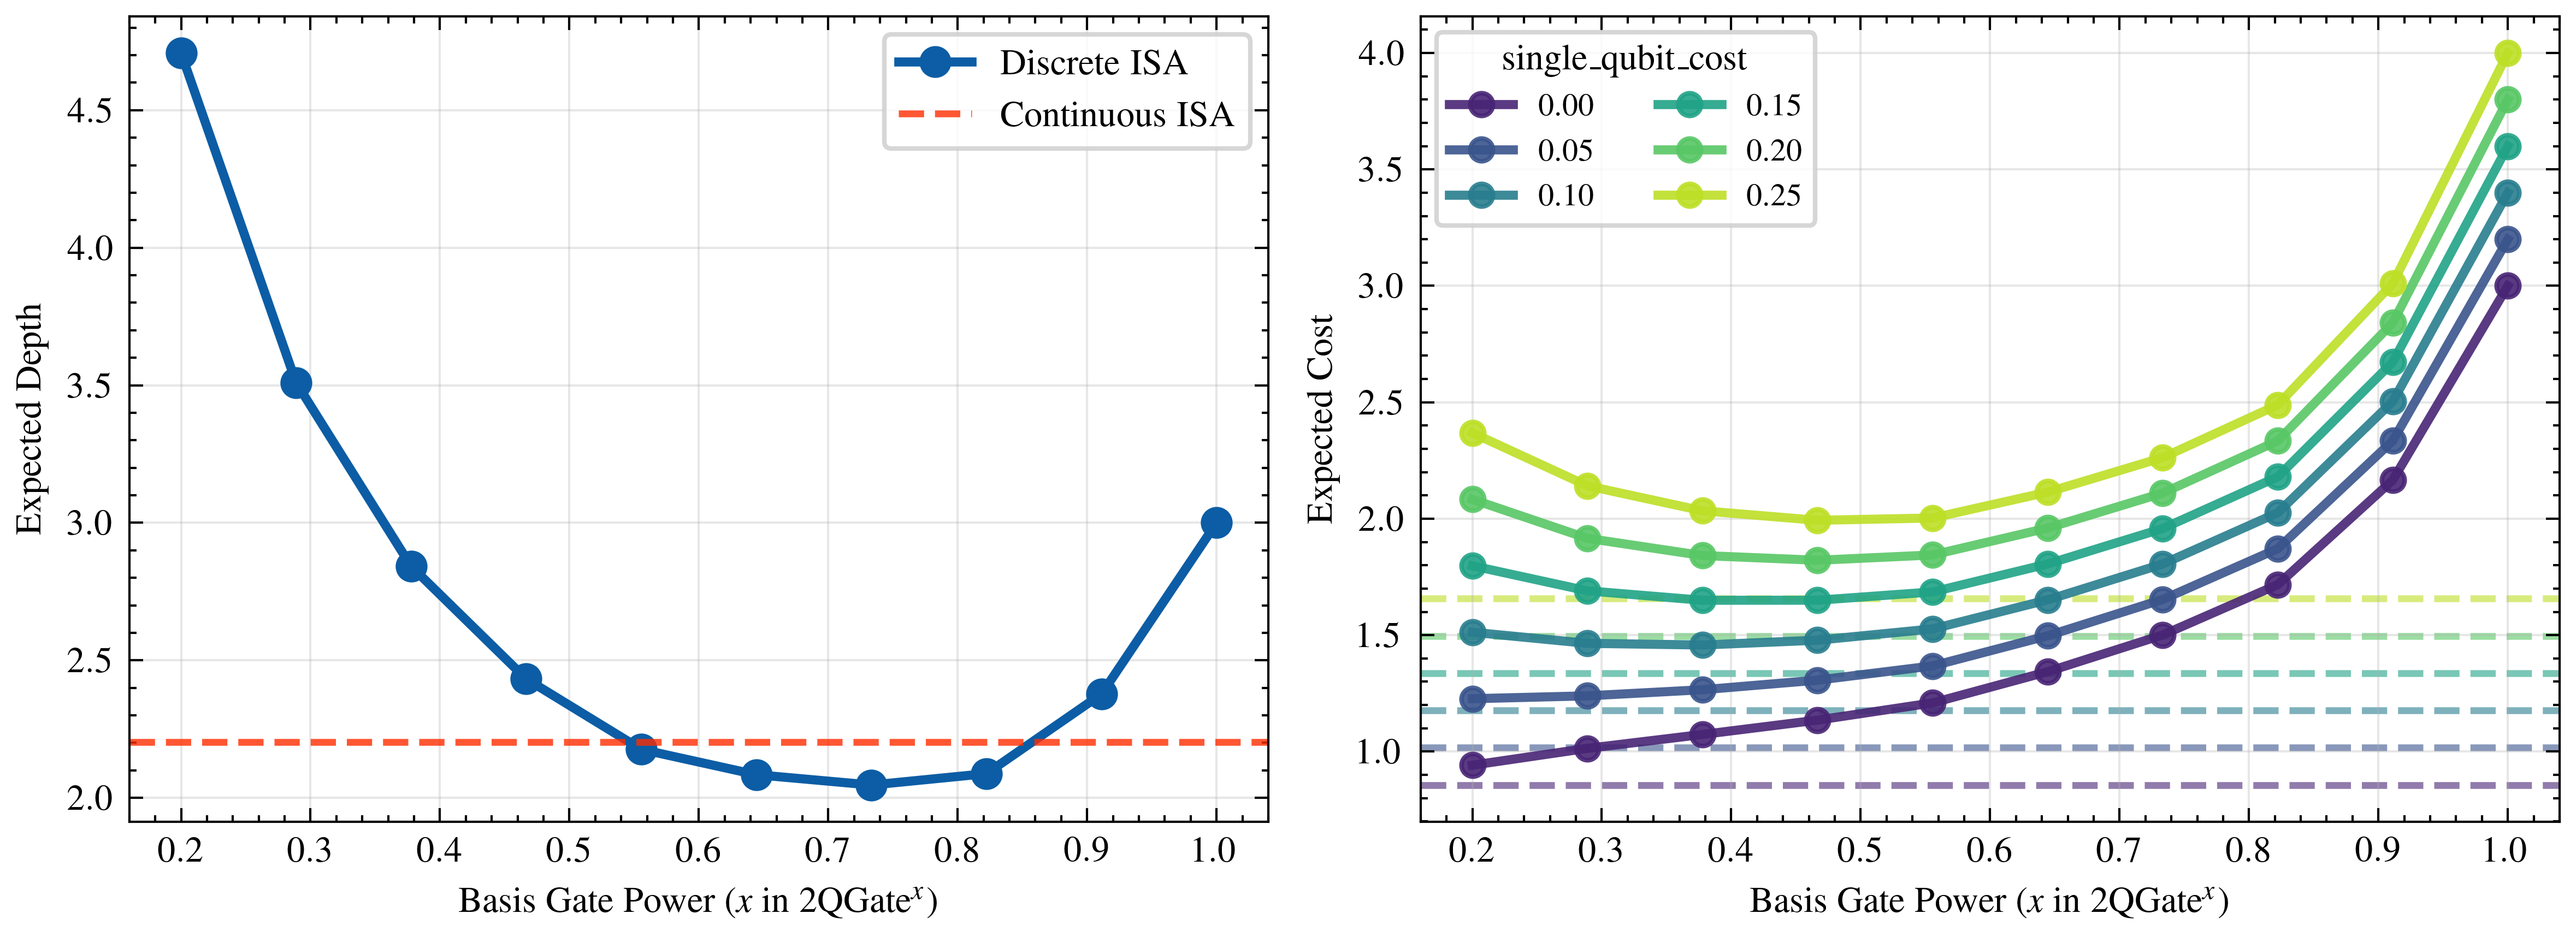

In [12]:
# Plot
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.0))

    # Left: Expected depth vs gate power
    axes[0].plot(x, depth, "-o", linewidth=2, markersize=6, label="Discrete ISA")
    if expected_depth is not None:
        axes[0].axhline(
            y=expected_depth,
            color="C3",
            linestyle="--",
            linewidth=1.5,
            label="Continuous ISA",
            alpha=0.8,
        )
    axes[0].set_xlabel(rf"Basis Gate Power ($x$ in {base_gate}$^x$)")
    axes[0].set_ylabel("Expected Depth")
    axes[0].legend(fontsize=8, loc="best", frameon=True)
    axes[0].grid(True, alpha=0.3)

    # Right: Expected cost vs gate power for different single_qubit_cost values
    # Use same colors for discrete curves and continuous limits
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(single_qubit_costs)))

    for i, sq_cost in enumerate(single_qubit_costs):
        # Discrete ISA curve (solid)
        label = f"{sq_cost:.2f}"
        axes[1].plot(
            x,
            cost_curves[sq_cost],
            "-o",
            linewidth=2,
            markersize=5,
            label=label,
            color=colors[i],
            alpha=0.9,
        )
        # Continuous ISA limit (dashed, matching color)
        if sq_cost in continuous_costs_by_sq:
            axes[1].axhline(
                y=continuous_costs_by_sq[sq_cost],
                color=colors[i],
                linestyle="--",
                linewidth=1.5,
                alpha=0.6,
                zorder=0,
            )

    # Add a single dummy line to legend for continuous limits
    if baseline_cost is not None:
        axes[1].plot(
            [],
            [],
            "--",
            color="gray",
            linewidth=1.5,
            alpha=0.6,
            # label="Continuous limit",
        )

    axes[1].set_xlabel(rf"Basis Gate Power ($x$ in {base_gate}$^x$)")
    axes[1].set_ylabel("Expected Cost")
    axes[1].legend(
        title="single\\_qubit\\_cost", fontsize=7, loc="best", frameon=True, ncol=2
    )
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()